In [1]:
using Images
include("../RayTracing.jl")

Main.RayTracing

# make albedo

┌ Warning: Premature end of JPEG byte sequence.
└ @ JpegTurbo /home/jmyslinski/.julia/packages/JpegTurbo/HKywP/src/decode.jl:220
┌ Warning: Premature end of JPEG byte sequence.
└ @ JpegTurbo /home/jmyslinski/.julia/packages/JpegTurbo/HKywP/src/decode.jl:220


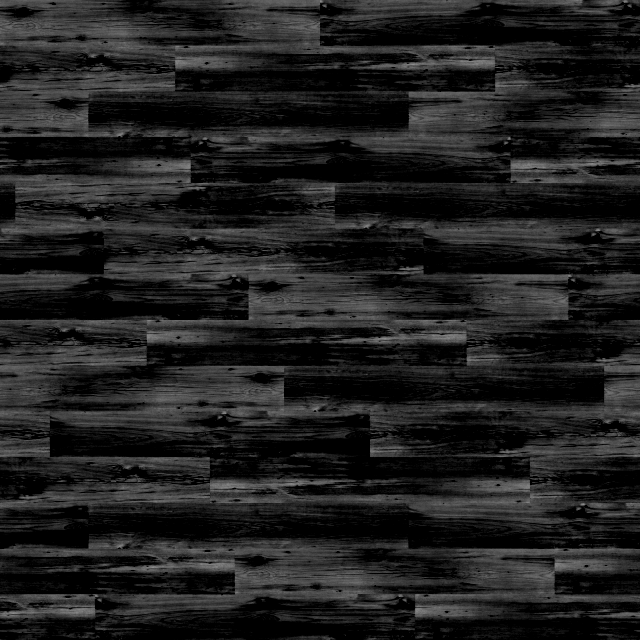

In [2]:
img = load(RayTracing.jmfp("/Users/johnmyslinski/Documents/pbrt-v3-scenes/bathroom/textures/WoodFine0034_7_S.jpg"))
gray_img = Gray.(img)

img_array = Float64.(gray_img)

# Apply contrast adjustment
contrast_factor = 3.0
contrasted_array = clamp.((img_array .- 0.5) .* contrast_factor .+ 0.5, 0, 1)

# Apply darkening and clamp again
contrasted_array = clamp.(contrasted_array .- 0.3, 0, 1)

# Apply scaling and clamp again
# contrasted_array = clamp.(contrasted_array .* 1.5, 0, 1)

# Apply power scaling and clamp again
# contrasted_array = clamp.(contrasted_array .^ .8, 0, 1)

# Convert back to image
enhanced_img = Gray.(contrasted_array)

In [3]:
save(RayTracing.jmfp("/Users/johnmyslinski/Documents/PBRJ/ref/elevator_wood_1_albedo.png"), enhanced_img)

# make specular

In [6]:
img = load(RayTracing.jmfp("/Users/johnmyslinski/Documents/pbrt-v3-scenes/bathroom/textures/WoodFine0034_7_S.jpg"))
gray_img = Gray.(img)

img_array = Float64.(gray_img)

# Apply contrast adjustment
contrast_factor = 5.0
contrasted_array = clamp.((img_array .- 0.5) .* contrast_factor .+ 0.5, 0, 1)

# Apply darkening and clamp again
contrasted_array = clamp.(contrasted_array .- 0.4, 0, 1)

# Apply scaling and clamp again
contrasted_array = clamp.(contrasted_array .* 1.5, 0, 1)

# Apply power scaling and clamp again
contrasted_array = clamp.(contrasted_array .^ .8, 0, 1)

# Convert back to image
enhanced_img = Gray.(contrasted_array)


save(RayTracing.jmfp("/Users/johnmyslinski/Documents/PBRJ/ref/elevator_wood_1_specular.png"), enhanced_img)

┌ Warning: Premature end of JPEG byte sequence.
└ @ JpegTurbo /home/jmyslinski/.julia/packages/JpegTurbo/HKywP/src/decode.jl:220
┌ Warning: Premature end of JPEG byte sequence.
└ @ JpegTurbo /home/jmyslinski/.julia/packages/JpegTurbo/HKywP/src/decode.jl:220


Generating bump map test textures...
Generated textures:
- Checkerboard: Sharp edges, good for testing normal calculation
- Sine waves: Smooth gradients, good for testing interpolation
- Ripples: Radial patterns, good for testing circular features
- Noise: Random variation, good for realistic surfaces
- Bricks: Architectural pattern, good for testing complex shapes

Example: Displaying checkerboard texture dimensions: (512, 512)


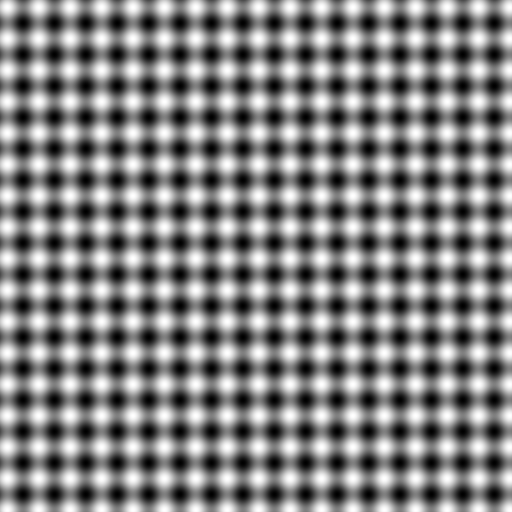

In [9]:
using Images, FileIO

"""
Generate a simple checkerboard pattern for bump mapping
"""
function checkerboard_texture(width::Int, height::Int, square_size::Int=32)
    texture = zeros(Gray{Float32}, height, width)
    
    for y in 1:height
        for x in 1:width
            # Determine which square we're in
            square_x = div(x - 1, square_size)
            square_y = div(y - 1, square_size)
            
            # Alternate between 0.0 and 1.0 based on square position
            if (square_x + square_y) % 2 == 0
                texture[y, x] = Gray{Float32}(0.0)  # Black (low height)
            else
                texture[y, x] = Gray{Float32}(1.0)  # White (high height)
            end
        end
    end
    
    return texture
end

"""
Generate a sine wave pattern for smooth bump mapping
"""
function sine_wave_texture(width::Int, height::Int, frequency::Float32=0.05f0)
    texture = zeros(Gray{Float32}, height, width)
    
    for y in 1:height
        for x in 1:width
            # Create a sine wave pattern
            value = (sin(x * frequency) + sin(y * frequency) + 2.0f0) / 4.0f0
            texture[y, x] = Gray{Float32}(value)
        end
    end
    
    return texture
end

"""
Generate a circular ripple pattern
"""
function ripple_texture(width::Int, height::Int, frequency::Float32=0.02f0)
    texture = zeros(Gray{Float32}, height, width)
    center_x = width / 2
    center_y = height / 2
    
    for y in 1:height
        for x in 1:width
            # Calculate distance from center
            distance = sqrt((x - center_x)^2 + (y - center_y)^2)
            
            # Create ripple pattern
            value = (sin(distance * frequency) + 1.0f0) / 2.0f0
            texture[y, x] = Gray{Float32}(value)
        end
    end
    
    return texture
end

"""
Generate a Perlin noise-like texture (simplified version)
"""
function noise_texture(width::Int, height::Int, scale::Float32=0.1f0)
    texture = zeros(Gray{Float32}, height, width)
    
    for y in 1:height
        for x in 1:width
            # Simple pseudo-random noise pattern
            # This is a basic implementation - for better results, use a proper noise library
            value1 = sin(x * scale * 0.7f0) * cos(y * scale * 0.3f0)
            value2 = sin(x * scale * 1.3f0) * cos(y * scale * 1.7f0)
            value3 = sin(x * scale * 2.1f0) * cos(y * scale * 2.9f0)
            
            combined = (value1 + value2 * 0.5f0 + value3 * 0.25f0)
            # Normalize to 0-1 range
            normalized = (combined + 1.75f0) / 3.5f0
            texture[y, x] = Gray{Float32}(clamp(normalized, 0.0f0, 1.0f0))
        end
    end
    
    return texture
end

"""
Generate a brick pattern texture
"""
function brick_texture(width::Int, height::Int, brick_width::Int=64, brick_height::Int=32, mortar_width::Int=4)
    texture = zeros(Gray{Float32}, height, width)
    
    for y in 1:height
        for x in 1:width
            # Determine which row of bricks we're in
            brick_row = div(y - 1, brick_height + mortar_width)
            y_in_brick = (y - 1) % (brick_height + mortar_width)
            
            # Offset every other row for brick pattern
            x_offset = (brick_row % 2) * (brick_width ÷ 2)
            adjusted_x = x + x_offset
            
            # Determine position within brick column
            x_in_brick = (adjusted_x - 1) % (brick_width + mortar_width)
            
            # Check if we're in mortar (gaps between bricks)
            if y_in_brick >= brick_height || x_in_brick >= brick_width
                texture[y, x] = Gray{Float32}(0.2f0)  # Mortar (low)
            else
                texture[y, x] = Gray{Float32}(0.8f0)  # Brick (high)
            end
        end
    end
    
    return texture
end

# Example usage - generate and save textures
function generate_test_textures(size::Int=512)
    println("Generating bump map test textures...")
    
    # Create different texture patterns
    checkerboard = checkerboard_texture(size, size, 32)
    sine_waves = sine_wave_texture(size, size, 0.2f0)
    ripples = ripple_texture(size, size, 0.015f0)
    noise = noise_texture(size, size, 0.05f0)
    bricks = brick_texture(size, size, 48, 24, 3)
    
    # Save textures (uncomment to save to files)
    # save("checkerboard_bump.png", checkerboard)
    # save("sine_wave_bump.png", sine_waves)
    # save("ripple_bump.png", ripples)
    # save("noise_bump.png", noise)
    # save("brick_bump.png", bricks)
    
    println("Generated textures:")
    println("- Checkerboard: Sharp edges, good for testing normal calculation")
    println("- Sine waves: Smooth gradients, good for testing interpolation")
    println("- Ripples: Radial patterns, good for testing circular features")
    println("- Noise: Random variation, good for realistic surfaces")
    println("- Bricks: Architectural pattern, good for testing complex shapes")
    
    return (
        checkerboard = checkerboard,
        sine_waves = sine_waves,
        ripples = ripples,
        noise = noise,
        bricks = bricks
    )
end

# Generate the textures
textures = generate_test_textures()

# Display one texture as an example
println("\nExample: Displaying checkerboard texture dimensions: ", size(textures.checkerboard))
textures.sine_waves

In [11]:
save(RayTracing.jmfp("/Users/johnmyslinski/Documents/PBRJ/ref/elevator_sine_waves.png"), textures.sine_waves)